In [1]:
import pandas as pd
import numpy as np
from scipy.integrate import trapezoid as trapz
import matplotlib.pyplot as plt
import h5py
from Phono3pyPowerTools.Phono3pyIO import Phono3pyKappaHDF5
from pymatgen.io.phonopy import get_gruneisenparameter
import scipy.constants as const
from pymatgen.core.units import amu_to_kg
import math

### MACE-MP03b

In [ ]:
with Phono3pyKappaHDF5('kappa-m61410.hdf5') as kappa_hdf5:  #this file is added into ZENODO
        freqs = kappa_hdf5.GetModeFreqs()
        tau = kappa_hdf5.GetModeTau(temp=300)

/home/jpineda/Phono3py-Power-Tools/Phono3pyPowerTools/Phono3pyIO.py:371: RuntimeWarning: divide by zero encountered in divide
  mode_gamma > 0.0, 1.0 / (2.0 * 2.0 * math.pi * mode_gamma), 0.0


In [3]:
MACE_frequency = freqs.flatten()
MACE_tau = tau.flatten()

### Analytical model

In [4]:
dat = np.loadtxt('total_dos.dat')
freq = dat[:, 0]                          # THz
DOS  = dat[:, 1]                          # arbitrary units (unnormalized)

omega = 2 * np.pi * freq * 1e12           # rad/s

# Normalize DOS over omega
intDOS = trapz(DOS, omega)
DOS = DOS / intDOS


N = 60               # atoms per primitive unit cell
n = 4.64E28          #atoms/m^3

vs=1601.382949794399 # m/s, harmonic mean SoS

omega_IR = (6 * np.pi ** 2 * n) ** (1 / 3) * vs * N ** (-1 / 3)
Prop_vals = np.where(omega < omega_IR)
Diff_vals = np.where(omega >= omega_IR)
life_omega = np.where(omega >= 0)
T  = 300
pi = np.pi
C1 =  11.805
A  =  0.015
C3 =  15.423
P  =  0.387
tau_complete= []
tau_C1_A    = []
tau_C1      = []
Freq        = []

if T==300:
    tau = (1/(((C1 * 1e-16 * omega[life_omega]**2 * T) + (A * omega[life_omega]) + (C3 * 1e-40 * omega[life_omega]**4))* 1E-12))
    tau_C3 = (1/(((C1 * 1e-16 * omega[life_omega]**2 * T) + (A * omega[life_omega]))* 1E-12))
    tau_C3_A = (1/(((C1 * 1e-16 * omega[life_omega]**2 * T) * 1E-12)))

    fre_arr = omega[life_omega]/(2*np.pi*1E12)

    tau_complete=tau
    tau_C1_A= (tau_C3)
    tau_C1=(tau_C3_A)
    Freq=(fre_arr)

## Grüneisen model

In [ ]:
pi = np.pi
gru = get_gruneisenparameter(gruneisen_path="/../Gruneisen_parameter/Ge/gruneisen_mesh.yaml")
volpc = (gru.structure.volume*(1E-30))
debye_freq = gru.debye_temp_phonopy()* const.value("Boltzmann constant in Hz/K") 
debye_freq = debye_freq*2*pi
freq=gru.frequencies*const.tera*2*pi

print('Debye_freq', debye_freq)

debye_omega = (gru.debye_temp_phonopy() * const.k)/const.hbar
print('Debye_omega', debye_omega)

freq = gru.frequencies*2*np.pi*const.tera

def life_time(theta_d=None, t=300):
	if gru.structure is None:
		raise ValueError("Structure is not defined.")

	average_mass = np.mean([s.specie.atomic_mass for s in gru.structure]) * amu_to_kg

	if theta_d is None:
		theta_d = gru.acustic_debye_temp
	mean_g = gru.average_gruneisen(t=t, squared=True, limit_frequencies='acoustic')
	v = (debye_omega)/ ((((6*np.pi ** 2) * (gru.structure.num_sites/volpc))) **(1/3)) #in m/s
	print('Sound velocity', v)
	p1 = (((1 - 0.514 * mean_g ** -1) + (0.228 * mean_g ** -2)) / 0.0948)
	p2 = ((const.hbar ** 2) * (mean_g ** 2)) / (const.k * theta_d * average_mass * v * ((volpc**(1/3))) )
	p= p1*p2
	tau = ((p * (freq)**2 * (t / theta_d)) *math.exp (-(theta_d) / (3 * t))) #Lifetime in s or
	tau_ps = (tau/const.tera)  #picosecondas

	return tau_ps

# get lifetimes at different temps
lifetimes = life_time(theta_d=gru.acoustic_debye_temp, t=300)
# lifetimes with gru multiplicity
lifetime_mat = []
freq_mat = []
for inx, qgru in enumerate(lifetimes):
	life_arr = []
	fre_arr = []
	for i in range(len(qgru)):
		life_arr.extend([qgru[i]] * gru.multiplicities[i])
		fre_arr.extend([gru.frequencies[inx][i]]*gru.multiplicities[i])

	lifetime_mat.append(life_arr)
	freq_mat.append(fre_arr)

GM_tau = np.array(lifetime_mat).flatten()
GM_freq = np.array(freq_mat).flatten()

Debye_freq 22707653333377.176
Debye_omega 22707653333377.17
Sound velocity 1601.9243697057257


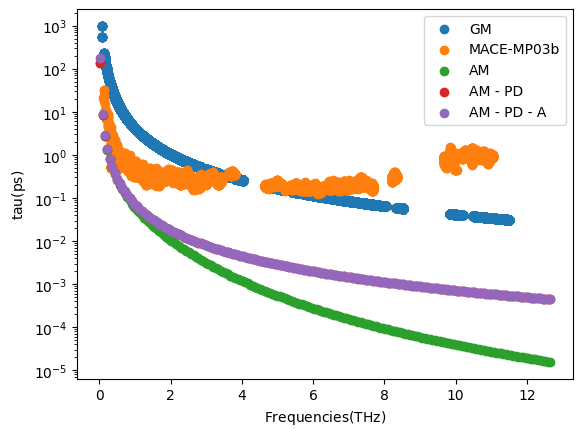

In [6]:
plt.scatter(GM_freq, 1/GM_tau, label='GM')
plt.scatter(MACE_frequency, MACE_tau, label='MACE-MP03b')
plt.scatter(Freq, tau_complete, label='AM')
plt.scatter(Freq, tau_C1_A, label='AM - PD')
plt.scatter(Freq, tau_C1, label='AM - PD - A')
plt.yscale('log')
plt.legend()
plt.ylabel(rf"$\mathrm{{tau (ps)}}$")
plt.xlabel(r"$\mathrm{Frequencies (THz)}$")
plt.savefig('Gamm_comp_models.tif')
plt.savefig('tau_comparison.tif')
plt.show()